# Analyse exploratoire des données

In [1]:
#Imports des librairies necessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Chargement du dataset et séparation des prix du reste des données

In [2]:
filepath = "home-data-for-ml-course/train.csv"

In [3]:
houses = pd.read_csv(filepath)

In [4]:
display(houses)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [5]:
prices = houses.SalePrice

## Étude de la répartition des prix des maisons

In [6]:
#affichage des différents deciles
prices.describe(percentiles=np.arange(0, 1, 0.1))

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
0%        34900.000000
10%      106475.000000
20%      124000.000000
30%      135500.000000
40%      147000.000000
50%      163000.000000
60%      179280.000000
70%      198620.000000
80%      230000.000000
90%      278000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [7]:
#affichage du decile supérieur
prices.describe(percentiles=np.arange(0.9, 1, 0.01))

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
50%      163000.000000
90%      278000.000000
91%      285000.000000
92%      295914.960000
93%      311305.000000
94%      318028.060000
95%      326100.000000
96%      344151.480000
97%      374230.000000
98%      394931.060000
99%      442567.010000
max      755000.000000
Name: SalePrice, dtype: float64

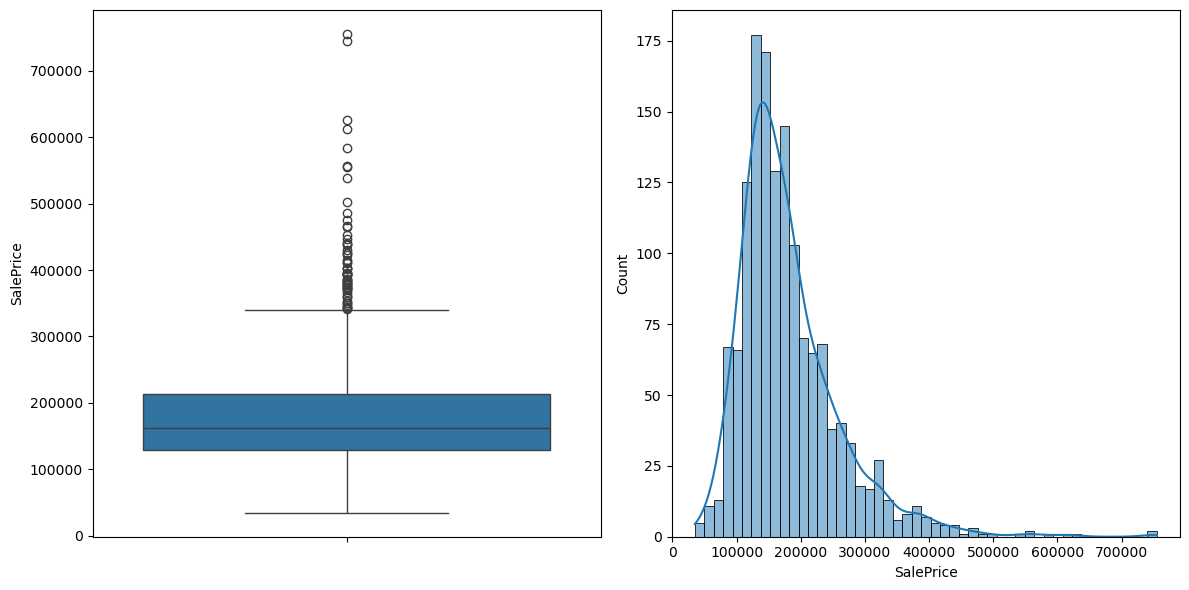

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(data=prices, ax=axes[0])
sns.histplot(data=prices, ax=axes[1], kde=True)
plt.tight_layout()
plt.show()

## Feature selection

A l'aide de methods comme value_counts(), describe() et corr() et à l'aide de scatter plots et de bar plots, je fais un tri dans les features présentes dans mon dataset.

In [9]:
houses.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [10]:
#exemple de l'utilisation de la method describe() pour connaître la variance et les différents deciles
houses['LotArea'].describe(percentiles=np.arange(0, 1, 0.1))

count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
0%         1300.000000
10%        5000.000000
20%        7078.400000
30%        8063.700000
40%        8793.400000
50%        9478.500000
60%       10198.200000
70%       11066.500000
80%       12205.800000
90%       14381.700000
max      215245.000000
Name: LotArea, dtype: float64

In [11]:
#exemple de l'utilisation de la method value_counts()
houses.GarageCond.fillna('noGarage', inplace=False).value_counts(normalize=True) * 100

GarageCond
TA          90.821918
noGarage     5.547945
Fa           2.397260
Gd           0.616438
Po           0.479452
Ex           0.136986
Name: proportion, dtype: float64

#### Affichage des colonne qui contiennent des valeurs nulles et de la proportion

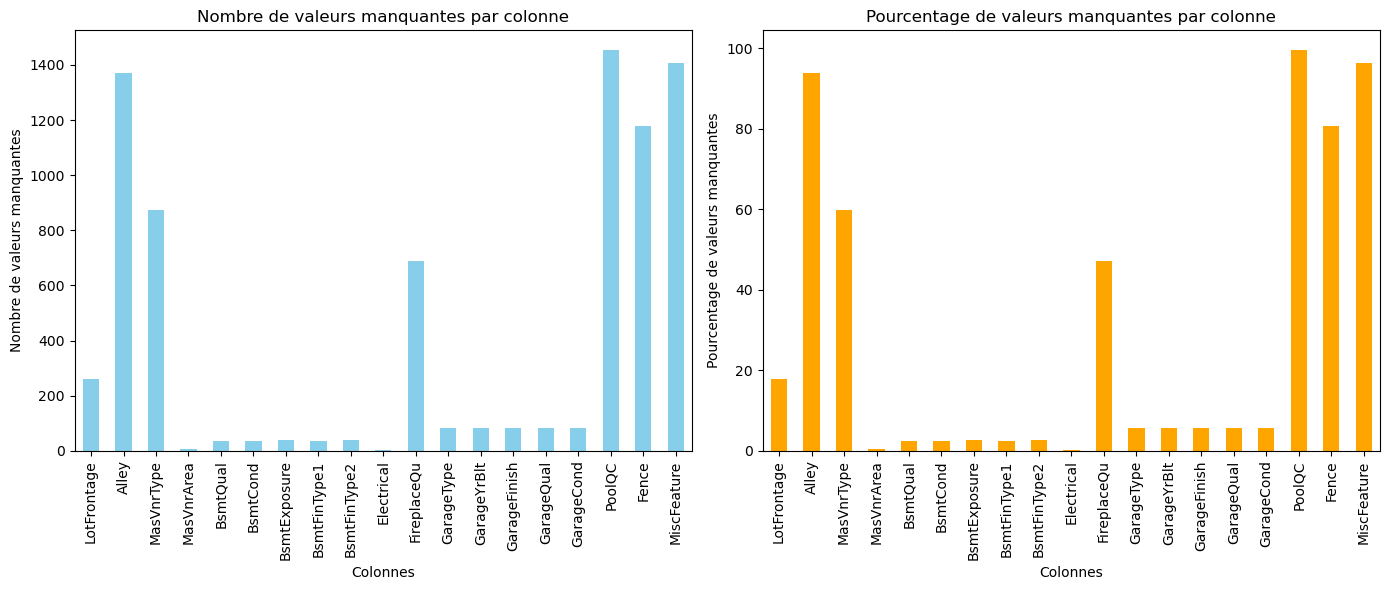

In [12]:
# Calculer le nombre de valeurs manquantes par colonne
missing_data_count = houses.isnull().sum()

# Calculer le pourcentage de valeurs manquantes par colonne
missing_data_percentage = (missing_data_count / len(houses)) * 100

# Filtrer les colonnes ayant des valeurs manquantes
missing_data_count = missing_data_count[missing_data_count > 0]
missing_data_percentage = missing_data_percentage[missing_data_percentage > 0]


# Créer un bar plot pour les valeurs manquantes
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Graphique du nombre de valeurs manquantes
missing_data_count.plot(kind='bar', color='skyblue', ax=ax[0])
ax[0].set_title('Nombre de valeurs manquantes par colonne')
ax[0].set_xlabel('Colonnes')
ax[0].set_ylabel('Nombre de valeurs manquantes')

# Graphique du pourcentage de valeurs manquantes
missing_data_percentage.plot(kind='bar', color='orange', ax=ax[1])
ax[1].set_title('Pourcentage de valeurs manquantes par colonne')
ax[1].set_xlabel('Colonnes')
ax[1].set_ylabel('Pourcentage de valeurs manquantes')

plt.tight_layout()
plt.show()

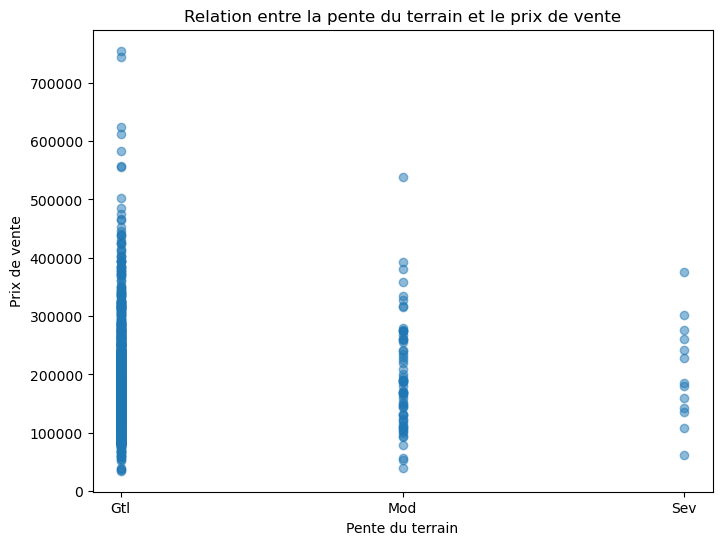

In [13]:
#exemple de scatter plot entre une variable et la variable cible
plt.figure(figsize=(8, 6))
plt.scatter(houses['LandSlope'], houses['SalePrice'], alpha=0.5)
plt.title('Relation entre la pente du terrain et le prix de vente')
plt.xlabel('Pente du terrain')
plt.ylabel('Prix de vente')
plt.show()

In [14]:
#exemple d'utilisation de la method corr() pour connaître la correlation entre une feature et la variable cible
display(houses.WoodDeckSF.corr(houses.SalePrice))

0.3244134445681296

In [15]:
#to drop
columns_to_drop = ["Id", 'Utilities', 'Alley', 'MSZoning', 'Street', 'LandContour', 'LotConfig', 'LandSlope', 'Condition2', 'HouseStyle', 'OverallCond', 'RoofStyle', 'RoofMatl', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'BsmtCond', 'BsmtExposure', 'BsmtUnfSF', 'Heating', 'CentralAir', 'Electrical', 'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath', 'HalfBath', 'KitchenAbvGr', 'Functional', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'Fence', 'MiscFeature', 'MiscVal', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition']

### Conclusion de l'exploration initiale

Suite à l'exploration préliminaire du dataset, plusieurs décisions ont été prises pour optimiser la qualité de l'analyse et de la modélisation :

- **Réduction des colonnes** : Environ 40 colonnes ont été éliminées en raison d'un nombre excessif de valeurs manquantes ou de leur potentiel à introduire des fuites de données.
- **Gestion des outliers** : Les données indiquent qu'au-delà d'un prix de **280 000 $**, le nombre de maisons devient trop faible, rendant les prédictions peu fiables dans cette plage.
- **Focus sur un sous-ensemble des données** : Plutôt que d'utiliser l'intégralité du dataset comme dans le cadre de la compétition Kaggle, le modèle final se concentrera uniquement sur les maisons avec un prix inférieur à **280 000 $**. Cela permettra d'améliorer la capacité du modèle à généraliser sur des données pertinentes.

Ces ajustements visent à garantir un apprentissage optimal et à éviter les biais liés à des données peu représentatives ou incohérentes.